In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

In [6]:
#pd.read_excel('data.xlsx')
df =  pd.read_excel('data.xlsx')

In [7]:
df.head(10)

,wave_height_m,wave_period_s,current_velocity_ms,tidal_range_m,grain_size_mm,sediment_density_kgm3,beach_slope,shoreline_orientation_deg,sediment_transport_rate,morphodynamic_index
0,2.098028,9.361282,1.135556,2.270661,0.227576,2774.096560,0.064910,311.740663,1.594007,1.251556
1,1.717041,5.745373,0.366696,2.166999,0.228917,2681.982306,0.076367,342.275723,1.417099,0.914485
2,2.188613,7.090445,1.114424,1.888868,0.473543,2803.884729,0.115661,116.862099,1.380342,1.067824
3,2.713818,7.102396,0.829883,1.537343,0.330931,2741.126228,0.107371,150.794786,1.864261,1.301335
4,1.659508,5.996432,1.112237,1.511250,0.498065,2597.654757,0.021980,258.926467,1.401876,1.075184
5,1.659518,4.255069,1.133080,1.881900,0.200304,2779.314808,0.039258,108.129536,1.695613,1.317231
6,2.747528,7.645949,1.382375,1.304165,0.241503,2676.386602,0.101642,271.371351,2.107348,1.630821
7,2.260461,6.877992,1.306036,0.558740,0.116787,2610.532029,0.100674,26.601172,2.207449,1.692923
8,1.518315,8.000481,1.303971,1.746002,0.169043,2677.838570,0.040291,188.459418,1.934142,1.517868
9,2.125536,5.932799,1.333101,0.934466,0.440191,2761.232682,0.090365,44.032854,1.319789,1.103766


# 2. Feature Selection & Scaling

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [12]:
X = df.drop(["sediment_transport_rate", "morphodynamic_index"], axis=1)
y = df["sediment_transport_rate"]

In [13]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)

# 3. Machine Learning Model

In [18]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=18,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,18
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# 4. Model Evaluation

In [19]:
y_pred = model.predict(X_test)

print("\nSediment Transport Prediction Performance")
print("------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.3f}")
print(f"R² Score: {r2_score(y_test, y_pred):.3f}")


Sediment Transport Prediction Performance
------------------------------------------------
Mean Absolute Error (MAE): 0.163
R² Score: 0.800


# 5. Feature Importance Analysis

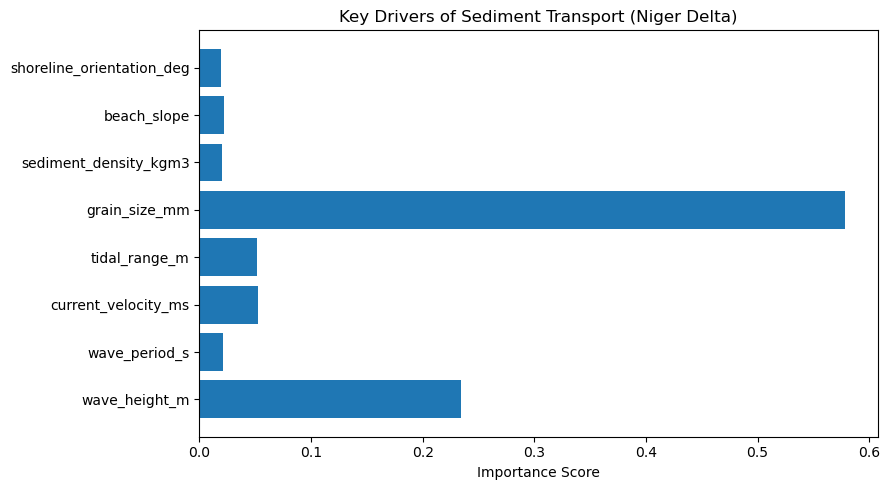

In [20]:
plt.figure(figsize=(9, 5))
plt.barh(X.columns, model.feature_importances_)
plt.xlabel("Importance Score")
plt.title("Key Drivers of Sediment Transport (Niger Delta)")
plt.tight_layout()
plt.show()

# 6. Coastal Morphodynamics Scenario Simulation

In [36]:
print("Training Features:", list(X.columns))

Training Features: ['wave_height_m', 'wave_period_s', 'current_velocity_ms', 'tidal_range_m', 'grain_size_mm', 'sediment_density_kgm3', 'beach_slope', 'shoreline_orientation_deg']



Scenario Simulation Result
------------------------------------------------
Predicted Sediment Transport Rate: 2.318 kg/m/s


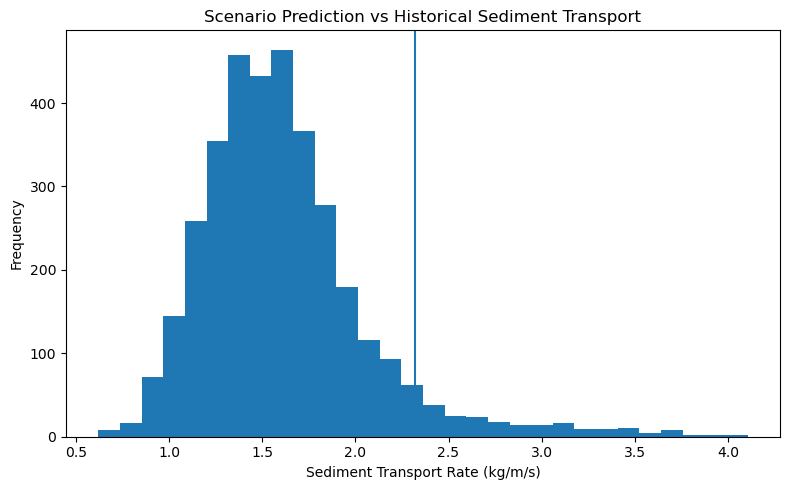

In [38]:
def morphodynamic_scenario():

    scenario_dict = {
        "wave_height_m": 3.2,
        "wave_period_s": 11,
        "current_velocity_ms": 1.8,
        "tidal_range_m": 2.9,
        "grain_size_mm": 0.18,
        "sediment_density_kgm3": 2650,
        "beach_slope": 0.08,
        "shoreline_orientation_deg": 120
    }

    scenario = pd.DataFrame([scenario_dict])
    scenario = scenario.reindex(columns=X.columns)

    scenario_scaled = scaler.transform(scenario)
    predicted_transport = model.predict(scenario_scaled)[0]

    print("\nScenario Simulation Result")
    print("------------------------------------------------")
    print(f"Predicted Sediment Transport Rate: {predicted_transport:.3f} kg/m/s")

    # 🔹 Visualization
    plt.figure(figsize=(8,5))
    
    # Plot historical distribution
    plt.hist(y, bins=30)
    
    # Plot scenario prediction line
    plt.axvline(predicted_transport)
    
    plt.xlabel("Sediment Transport Rate (kg/m/s)")
    plt.ylabel("Frequency")
    plt.title("Scenario Prediction vs Historical Sediment Transport")
    plt.tight_layout()
    plt.show()


# Run simulation
morphodynamic_scenario()


Storm vs Calm Condition Comparison
------------------------------------------------
Calm Condition Transport Rate : 1.078 kg/m/s
Storm Condition Transport Rate: 2.387 kg/m/s


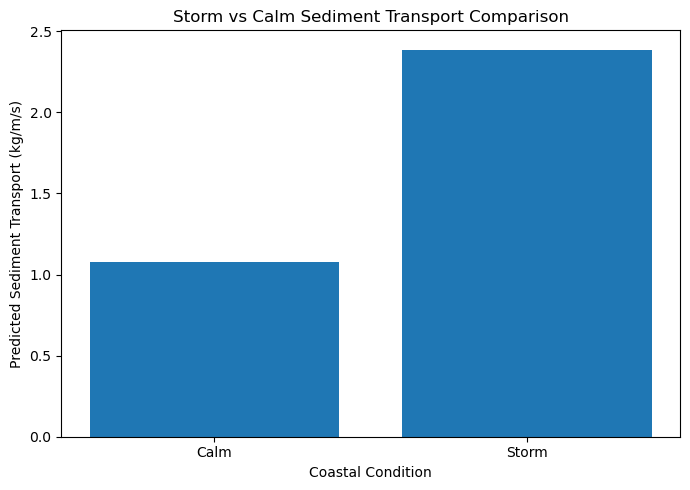

In [39]:
def storm_vs_calm_simulation():

    # Calm Condition
    calm = pd.DataFrame([{
        "wave_height_m": 0.8,
        "wave_period_s": 6,
        "current_velocity_ms": 0.5,
        "tidal_range_m": 1.2,
        "grain_size_mm": 0.25,
        "sediment_density_kgm3": 2650,
        "beach_slope": 0.05,
        "shoreline_orientation_deg": 120
    }])

    # Storm Condition
    storm = pd.DataFrame([{
        "wave_height_m": 4.0,
        "wave_period_s": 14,
        "current_velocity_ms": 2.5,
        "tidal_range_m": 3.5,
        "grain_size_mm": 0.18,
        "sediment_density_kgm3": 2650,
        "beach_slope": 0.08,
        "shoreline_orientation_deg": 120
    }])

    # Ensure correct column alignment
    calm = calm.reindex(columns=X.columns)
    storm = storm.reindex(columns=X.columns)

    # Scale using trained scaler
    calm_scaled = scaler.transform(calm)
    storm_scaled = scaler.transform(storm)

    # Predict
    calm_prediction = model.predict(calm_scaled)[0]
    storm_prediction = model.predict(storm_scaled)[0]

    print("\nStorm vs Calm Condition Comparison")
    print("------------------------------------------------")
    print(f"Calm Condition Transport Rate : {calm_prediction:.3f} kg/m/s")
    print(f"Storm Condition Transport Rate: {storm_prediction:.3f} kg/m/s")

    # 🔹 Visualization
    plt.figure(figsize=(7,5))
    conditions = ["Calm", "Storm"]
    predictions = [calm_prediction, storm_prediction]

    plt.bar(conditions, predictions)
    plt.xlabel("Coastal Condition")
    plt.ylabel("Predicted Sediment Transport (kg/m/s)")
    plt.title("Storm vs Calm Sediment Transport Comparison")
    plt.tight_layout()
    plt.show()


# Run comparison
storm_vs_calm_simulation()

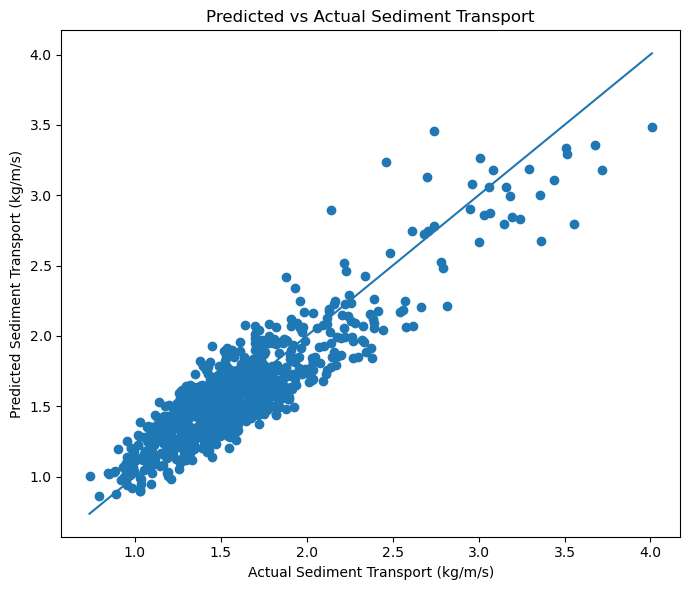

In [40]:
plt.figure(figsize=(7,6))

# Scatter plot
plt.scatter(y_test, y_pred)

# 1:1 reference line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Sediment Transport (kg/m/s)")
plt.ylabel("Predicted Sediment Transport (kg/m/s)")
plt.title("Predicted vs Actual Sediment Transport")
plt.tight_layout()
plt.show()

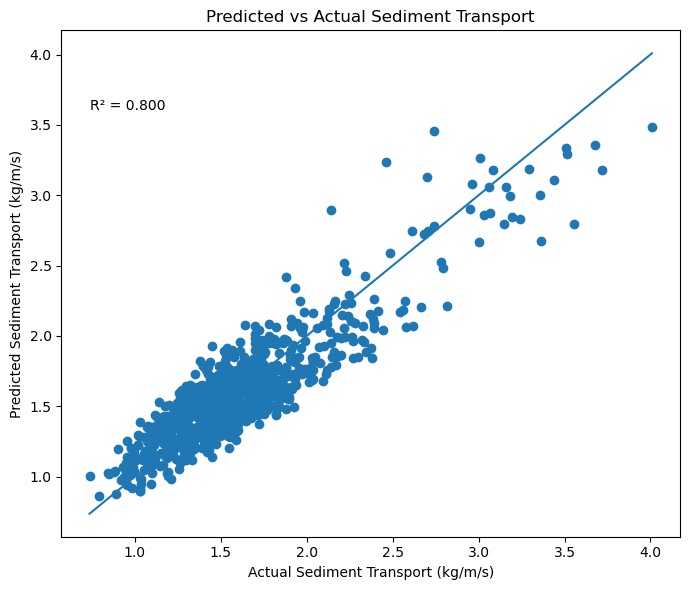

In [41]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.text(min_val, max_val*0.9, f"R² = {r2_score(y_test, y_pred):.3f}")

plt.xlabel("Actual Sediment Transport (kg/m/s)")
plt.ylabel("Predicted Sediment Transport (kg/m/s)")
plt.title("Predicted vs Actual Sediment Transport")
plt.tight_layout()
plt.show()

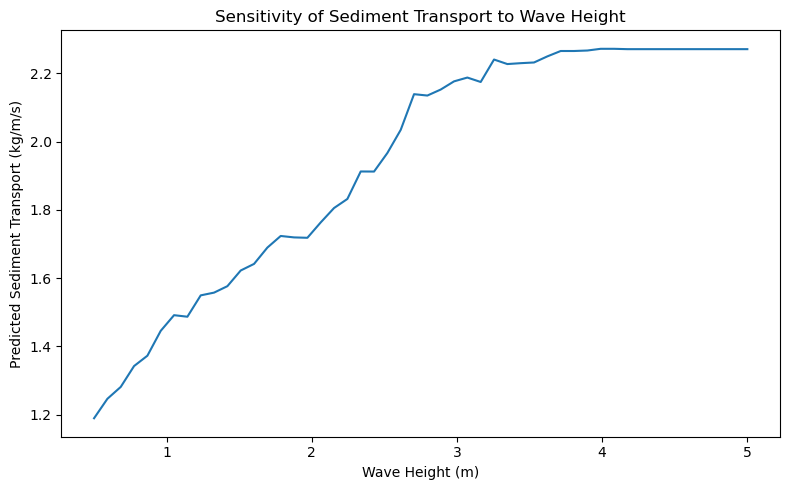

In [42]:
def wave_height_sensitivity():

    # Base scenario (typical coastal condition)
    base_scenario = {
        "wave_height_m": 1.0,  # will vary
        "wave_period_s": 8,
        "current_velocity_ms": 1.0,
        "tidal_range_m": 2.0,
        "grain_size_mm": 0.20,
        "sediment_density_kgm3": 2650,
        "beach_slope": 0.06,
        "shoreline_orientation_deg": 120
    }

    # Wave height range (calm to extreme storm)
    wave_heights = np.linspace(0.5, 5.0, 50)

    predictions = []

    for h in wave_heights:
        scenario = base_scenario.copy()
        scenario["wave_height_m"] = h

        scenario_df = pd.DataFrame([scenario])
        scenario_df = scenario_df.reindex(columns=X.columns)

        scenario_scaled = scaler.transform(scenario_df)
        pred = model.predict(scenario_scaled)[0]

        predictions.append(pred)

    # Plot
    plt.figure(figsize=(8,5))
    plt.plot(wave_heights, predictions)
    plt.xlabel("Wave Height (m)")
    plt.ylabel("Predicted Sediment Transport (kg/m/s)")
    plt.title("Sensitivity of Sediment Transport to Wave Height")
    plt.tight_layout()
    plt.show()


# Run analysis
wave_height_sensitivity()

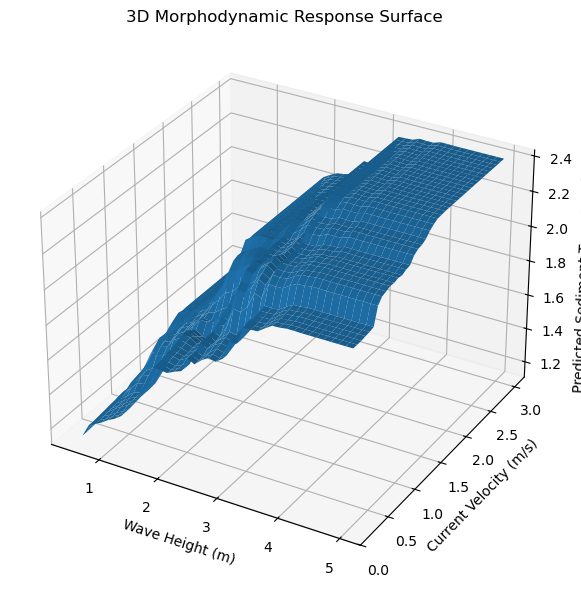

In [43]:
from mpl_toolkits.mplot3d import Axes3D

def morphodynamic_response_surface():

    # Base coastal condition
    base_scenario = {
        "wave_height_m": 1.5,  # will vary
        "wave_period_s": 8,
        "current_velocity_ms": 1.0,  # will vary
        "tidal_range_m": 2.0,
        "grain_size_mm": 0.20,
        "sediment_density_kgm3": 2650,
        "beach_slope": 0.06,
        "shoreline_orientation_deg": 120
    }

    # Create parameter ranges
    wave_range = np.linspace(0.5, 5.0, 40)
    current_range = np.linspace(0.2, 3.0, 40)

    W, C = np.meshgrid(wave_range, current_range)
    Z = np.zeros_like(W)

    # Predict across grid
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):

            scenario = base_scenario.copy()
            scenario["wave_height_m"] = W[i, j]
            scenario["current_velocity_ms"] = C[i, j]

            scenario_df = pd.DataFrame([scenario])
            scenario_df = scenario_df.reindex(columns=X.columns)

            scenario_scaled = scaler.transform(scenario_df)
            Z[i, j] = model.predict(scenario_scaled)[0]

    # Plot 3D surface
    fig = plt.figure(figsize=(9,6))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(W, C, Z)

    ax.set_xlabel("Wave Height (m)")
    ax.set_ylabel("Current Velocity (m/s)")
    ax.set_zlabel("Predicted Sediment Transport (kg/m/s)")
    ax.set_title("3D Morphodynamic Response Surface")

    plt.tight_layout()
    plt.show()


# Run surface simulation
morphodynamic_response_surface()